# Introduction

This project analyzes daily weather data for Kraljevo, Serbia, during the year 2025.
The analysis was performed using Python, Pandas, Matplotlib, and Meteostat.

The main objective was to explore temperature and wind speed patterns throughout the year, identify extreme weather events, and calculate basic climate indicators such as summer, tropic and frost days.

The project demonstrates the use of Python for meteorological data retrieval, processing, statistical analysis, and visualization.

# Data Collection

Weather data were obtained from the Meteostat database.
The selected station was:
- Station ID: 13376
- Station Name: Kraljevo

# Importing Libraries

In [9]:
import meteostat
import pandas as pd
import matplotlib.pyplot as plt
from meteostat import Point
from datetime import datetime

# Defining the Location

In [11]:
Kraljevo = Point (43.72, 20.69)

# Finding the nearest weather stations

In [13]:
s = meteostat.stations
nearest = s.nearby(Kraljevo)
nearest

,name,country,region,latitude,longitude,elevation,timezone,distance
id,,,,,,,,
13376,Kraljevo,RS,RS,43.7000,20.7000,215,Europe/Belgrade,2364.7
LYKV0,Kraljevo/ladjevci,RS,RS,43.8181,20.5861,201,Europe/Belgrade,13732.9
13278,Kragujevac / Petrovac,CS,SU,44.0333,20.9333,183,Europe/Belgrade,39924.1
13378,Kopaonik,RS,RS,43.2833,20.8000,1711,Europe/Belgrade,49362.7


# Selecting the weather station

In [15]:
nearest.iloc[0]

name                Kraljevo
country                   RS
region                    RS
latitude                43.7
longitude               20.7
elevation                215
timezone     Europe/Belgrade
distance              2364.7
Name: 13376, dtype: object

In [16]:
station_id = "13376"

# Downloading daily weather data

In [19]:
data = meteostat.daily(station_id,
                       datetime (2025, 1, 1),
                       datetime (2025, 12, 31)
                      )

A TimeSeries object was created containing daily weather data for Kraljevo during 2025.
At this stage, the data structure is defined, but the observations have not yet been loaded into memory.

In [22]:
data.fetch()

,temp,tmin,tmax,rhum,prcp,snwd,wspd,wpgt,pres,tsun,cldc
time,,,,,,,,,,,
2025-01-01,-1.6,-4.8,4.8,94,0.0,<NA>,0.8,11.1,1032.2,<NA>,2
2025-01-02,-0.8,-5.6,8.0,90,0.0,<NA>,2.5,11.1,1023.4,<NA>,2
2025-01-03,1.1,-2.4,6.5,92,11.8,<NA>,6.8,16.7,1017.9,<NA>,6
2025-01-04,-3.5,-6.9,1.2,94,0.4,<NA>,1.0,14.8,1025.4,<NA>,1
2025-01-05,-4.4,-7.6,1.1,92,0.0,<NA>,0.7,9.3,1022.6,<NA>,4
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,2.5,-1.9,6.6,84,0.0,<NA>,6.6,18.5,1027.6,<NA>,4
2025-12-28,1.8,-3.0,5.6,75,0.0,<NA>,13.3,58.0,1022.3,<NA>,6
2025-12-29,1.6,-2.8,9.4,68,0.0,<NA>,5.5,20.4,1020.7,<NA>,1


The fetch() method downloads the weather observations and loads them into the TimeSeries object.

In [23]:
df = data._df

The downloaded observations were stored in a Pandas DataFrame named df.

In [24]:
df.head()

temp  tmin  tmax  rhum  prcp  snwd  \
station time       source                                                   
13376   2025-01-01 dwd_mosmix          <NA>  <NA>  <NA>  <NA>   0.0  <NA>   
                   dwd_mosmix dwd_poi  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>   
                   dwd_poi             -1.6  -4.8   4.8    94  <NA>  <NA>   
        2025-01-02 dwd_mosmix          <NA>  <NA>  <NA>  <NA>   0.0  <NA>   
                   dwd_poi             -0.8  -5.6   8.0    90  <NA>  <NA>   

                                       wspd  wpgt    pres  tsun  cldc  
station time       source                                              
13376   2025-01-01 dwd_mosmix          <NA>  11.1    <NA>  <NA>  <NA>  
                   dwd_mosmix dwd_poi  <NA>  <NA>    <NA>  <NA>     2  
                   dwd_poi              0.8  <NA>  1032.2  <NA>  <NA>  
        2025-01-02 dwd_mosmix          <NA>  11.1    <NA>  <NA>  <NA>  
                   dwd_poi              2.5  <NA>  1023.4  <NA>  <NA>

The first rows of the dataset show that observations are available from multiple data sources.
The dataset uses a MultiIndex structure consisting of station ID, date and source.

In [25]:
df_poi = df.xs("dwd_poi", level = "source")
df_plot = df_poi.reset_index()
df_plot.head()

,station,time,temp,tmin,tmax,rhum,prcp,snwd,wspd,wpgt,pres,tsun,cldc
0,13376,2025-01-01,-1.6,-4.8,4.8,94,<NA>,<NA>,0.8,<NA>,1032.2,<NA>,<NA>
1,13376,2025-01-02,-0.8,-5.6,8.0,90,<NA>,<NA>,2.5,<NA>,1023.4,<NA>,<NA>
2,13376,2025-01-03,1.1,-2.4,6.5,92,<NA>,<NA>,6.8,<NA>,1017.9,<NA>,6
3,13376,2025-01-04,-3.5,-6.9,1.2,94,<NA>,<NA>,1.0,<NA>,1025.4,<NA>,<NA>
4,13376,2025-01-05,-4.4,-7.6,1.1,92,<NA>,<NA>,<NA>,<NA>,1022.6,<NA>,<NA>


To avoid duplicate observations, only records from the dwd_poi source were selected.
The index was then reset to create a clean DataFrame suirable for statistical analysis and visualization.

# Temperature Analysis

In [26]:
df_plot["temp"].describe()

count        354.0
mean     13.133333
std       8.813849
min           -4.4
25%          6.025
50%           12.9
75%           20.9
max           30.7
Name: temp, dtype: Float64

Analysis based on 354 daily station observations.
The average temperature in Kraljevo during 2025 was 13.1°C.
The coldest day recorded a mean temperature of -4.4°C, while the highest daily mean temperature was 30.7°C.

In [36]:
summer_days = (df_plot["tmax"] >= 25).sum()
tropical_days = (df_plot["tmax"] >= 30).sum()
frost_days = (df_plot["tmin"] < 0).sum()
ice_days = (df_plot["tmax"] < 0).sum()
print ("Number of summer days was", summer_days)
print ("Number of tropical days was", tropical_days)
print ("Number of frost days was", frost_days)
print  ("Number of ice days was", ice_days)

Number of summer days was 115
Number of tropical days was 68
Number of frost days was 64
Number of ice days was 5


Climate indices were calculated using daily minimum and maximum temperatures.

In 2025, Kraljevo experienced:
- 115 summer days (Tmax ≥ 25°C), which is almost a third of available data (354)
- out of those summer days more than a half (68) were tropical (Tmax ≥ 30°C)
- 64 frost days (Tmin < 0°C)
- only 5 ice days (Tmax < 0°C)

These values indicate a warm summer season with a large number of hot days, while winter conditions were relatively moderate with only a few ice days.

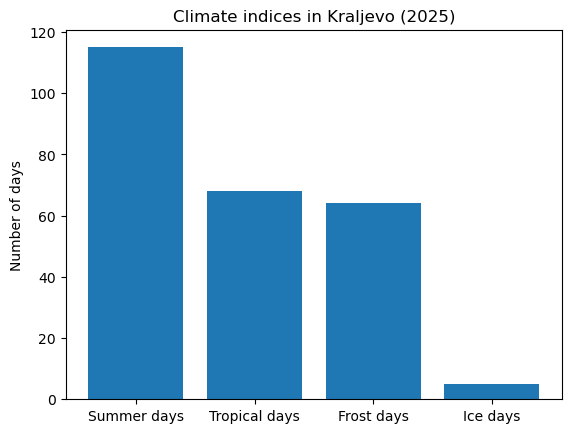

In [44]:
import matplotlib.pyplot as plt

indices = {
    "Summer days": summer_days,
    "Tropical days": tropical_days,
    "Frost days": frost_days,
    "Ice days": ice_days
}

plt.bar(indices.keys(),     #names
        indices.values())   #values

plt.title("Climate indices in Kraljevo (2025)")
plt.ylabel("Number of days")

plt.show()

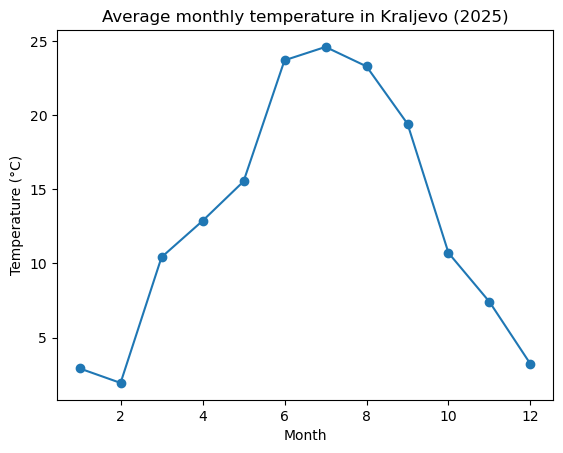

In [42]:
monthly_temp = df_plot.groupby(df_plot["time"].dt.month)["temp"].mean()

#takes month number from the date, groups days by month and creates monthly temperature for the graph

monthly_temp.plot(kind="line", marker="o")

#line graph

plt.title("Average monthly temperature in Kraljevo (2025)")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

Monthly mean temperatures show a clear seasonal cycle. The warmest mon th was July and the coldest was February.

# Wind Analysis

In [45]:
df_plot["wspd"].describe()

count       349.0
mean     6.236963
std      2.960911
min           0.8
25%           4.2
50%           5.7
75%           7.4
max          18.4
Name: wspd, dtype: Float64

Analysis based on 349 daily station observations.
The average wind speed during 2025 was 6.24 km/h.
The minimum was 0.8 km/h, and maximum 18.4 km/h.

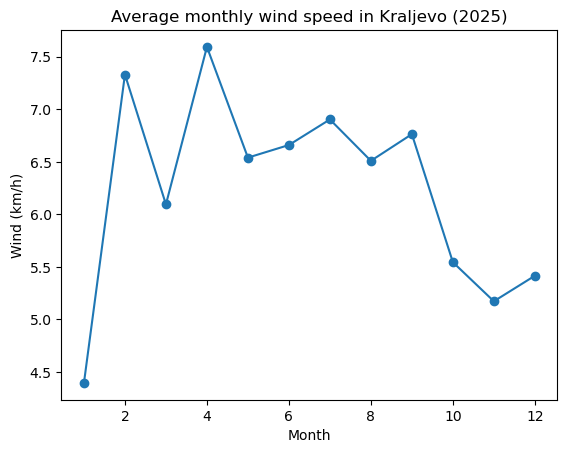

In [50]:
monthly_wind = df_plot.groupby(df_plot["time"].dt.month)["wspd"].mean()

monthly_wind.plot(kind="line", marker="o")

plt.title("Average monthly wind speed in Kraljevo (2025)")
plt.xlabel("Month")
plt.ylabel("Wind (km/h)")
plt.show()

Wind speed remained relatively stable during the summer months, generally ranging between 6.5 and 7 km/h. A decrease occured during autumn and early winter, when average wind speeds dropped below 6 km/h.

# Conclusion

This project analyzed daily temperature and wind observations for Kraljevo during 2025 using Python, Pandas and Meteostat data.

The average annual temperature was 13.1°C. The coldest day recorded a mean temperature of -4.4°C, while the highest daily temperature was 30.7°C.

A total of 115 summer days, 68 tropical days, 64 frost days and 5 ice days were recorded, indicating a long and warm summer season and a relatively moderate winter.

Monthly temperature analysis showed the expected seasonal cycle, with the highest temperature during July and August and the lowest during January and February.

The average wind speed was 6.2 km/h. Wind speeds were generally weak to moderate throughout the year.

Overall, the results provide a climatological overview of temperature and wind conditions in Kraljevo during 2025 and demonstrate data analysis and visualization techniques in Python.